<a href="https://colab.research.google.com/github/derlux4/Alura-Store/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



Introducción:

El presente análisis tiene como objetivo evaluar el desempeño entre las cuatro sucursales, para determinar su viabilidad operativa, proporcionando al Sr. Juan, una base solida para la toma de decisiones.

In [23]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [27]:
tienda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [25]:
import numpy as np

#1. Análisis de facturación



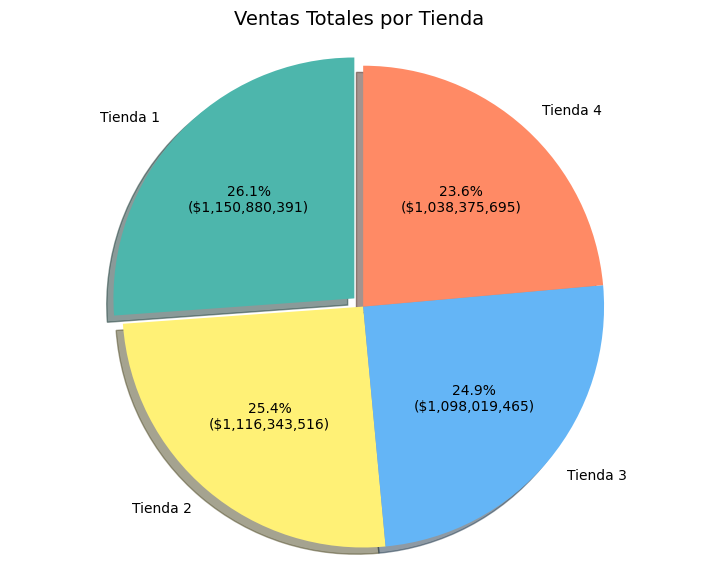

In [42]:
import matplotlib.pyplot as plt

#Primero calculamos la suma total del Precio por cada DataFrame y creamos etiquetas de nombres

ventas=[tienda['Precio'].sum(),
        tienda2['Precio'].sum(),
        tienda3['Precio'].sum(),
        tienda4['Precio'].sum(),
        ]

nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

#Configuramos el gráfico de pastel
plt.figure(figsize=(9, 7))
colores = ['#4db6ac', '#fff176', '#64b5f6', '#ff8a65']

#Creamos la función para la venta
def fmt(x, allvals):
    absolute = int(x/100.*sum(allvals))
    return "{:.1f}%\n(${:,.0f})".format(x, absolute)

plt.pie(
    ventas,
    labels=nombres_tiendas,
    autopct=lambda pct: fmt(pct, ventas),      # Agregamos los importes de venta
    startangle=90,          # Rota el inicio del gráfico
    colors=colores,
    explode=(0.05, 0, 0, 0), # Resalta ligeramente la primera rebanada
    shadow=True
)

plt.title('Ventas Totales por Tienda', fontsize=14)
plt.axis('equal')           # Asegura que el pastel sea un círculo perfecto
plt.show()

La Tienda 1 presenta el mayor ingreso, seguida por la Tienda 2. La Tienda 4 tiene el menor desempeño, lo cual puede influir en la decisión final del negocio.

A pesar de ello, la diferencia de ventas entre la que más vende (Tienda 1) en comparación con la (Tienda 4), es solo del 2.5%, lo cual indica que existe una venta consistente entre todas las tiendas.



# 2. Ventas por categoría

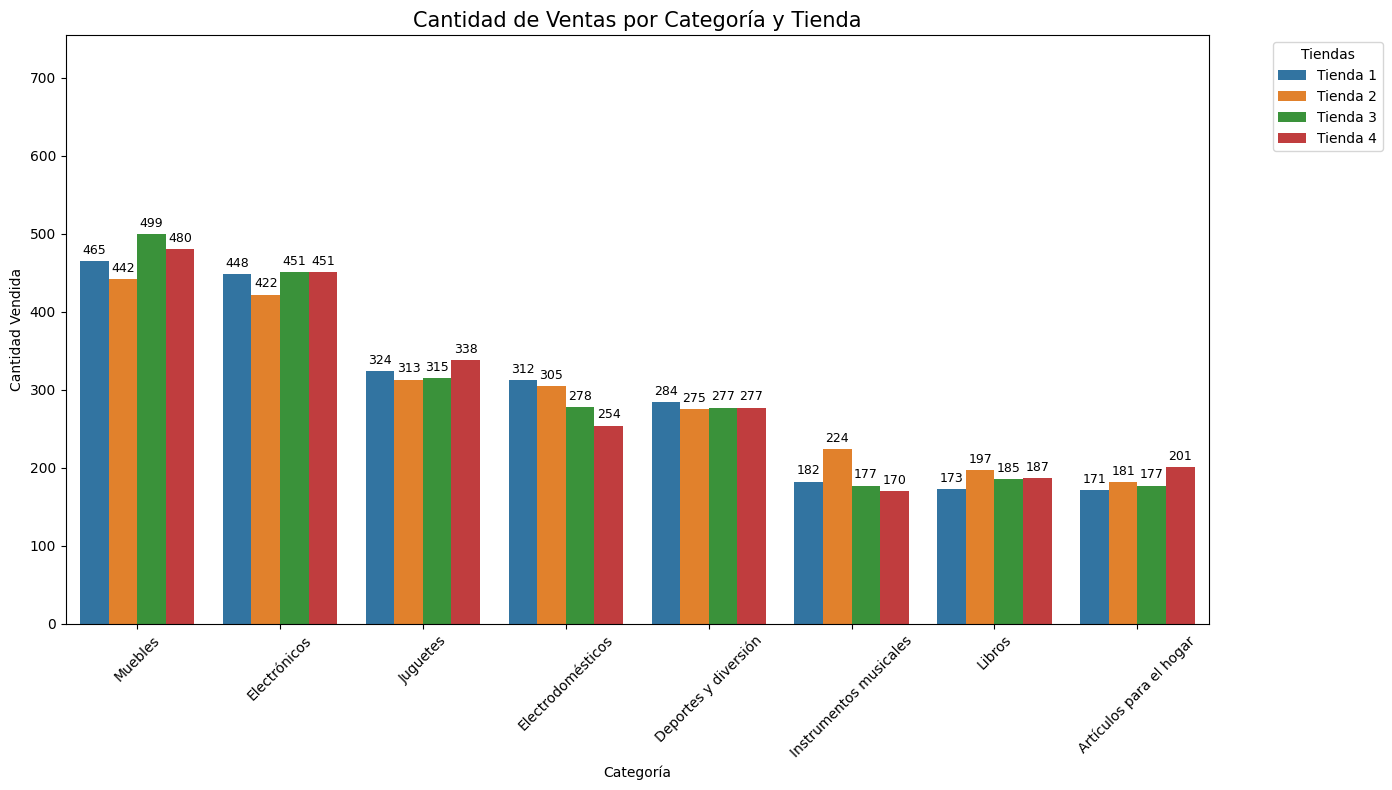

In [46]:
import seaborn as sns

#Unimos los datos
df_total = pd.concat([tienda, tienda2, tienda3, tienda4], keys=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'])
df_total = df_total.reset_index(level=0).rename(columns={'level_0': 'Tienda'})

#Ordenamos
orden_categorias = df_total['Categoría del Producto'].value_counts().index

#Creamos el gráfico
plt.figure(figsize=(14, 8))
ax = sns.countplot(
    data=df_total,
    x='Categoría del Producto',
    hue='Tienda',
    order=orden_categorias
)

#Estética final
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
plt.title('Cantidad de Ventas por Categoría y Tienda', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Cantidad Vendida')
plt.xlabel('Categoría')
plt.ylim(0, df_total['Categoría del Producto'].value_counts().max() * 0.4)
plt.legend(title='Tiendas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Las categorías más vendidas corresponden a muebles y electrónicos.  Mientras que mis artículos con menor rotación son libros y articulos para el hogar.

Se observa que las ventas por cada una de las tiendas en diferentes categorías es similar.

# 3. Calificación promedio de la tienda


/tmp/ipykernel_570/4179965250.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


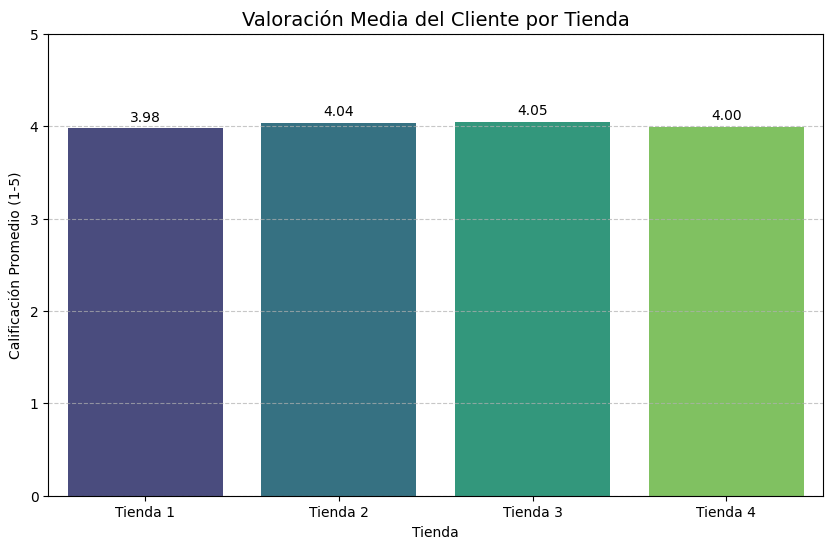

Resumen de valoración media:
     Tienda  Calificación
0  Tienda 1      3.976685
1  Tienda 2      4.037304
2  Tienda 3      4.048326
3  Tienda 4      3.995759


In [47]:
#Agrupamos y calculamos el promedio de calificación
valoracion_media = df_total.groupby('Tienda')['Calificación'].mean().reset_index()
#Visualización: Gráfico de barras de la calificación media
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=valoracion_media,
    x='Tienda',
    y='Calificación',
    palette='viridis'
)

#Agregar etiquetas con el valor promedio exacto
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Valoración Media del Cliente por Tienda', fontsize=14)
plt.ylabel('Calificación Promedio (1-5)')
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Mostrar tabla resumen
print("Resumen de valoración media:")
print(valoracion_media)

Se observa que la valoración de los clientes en las tiendas es bastante similar, esto indica una estandarización en el servicio satisfactoria.

# 4. Productos más y menos vendidos

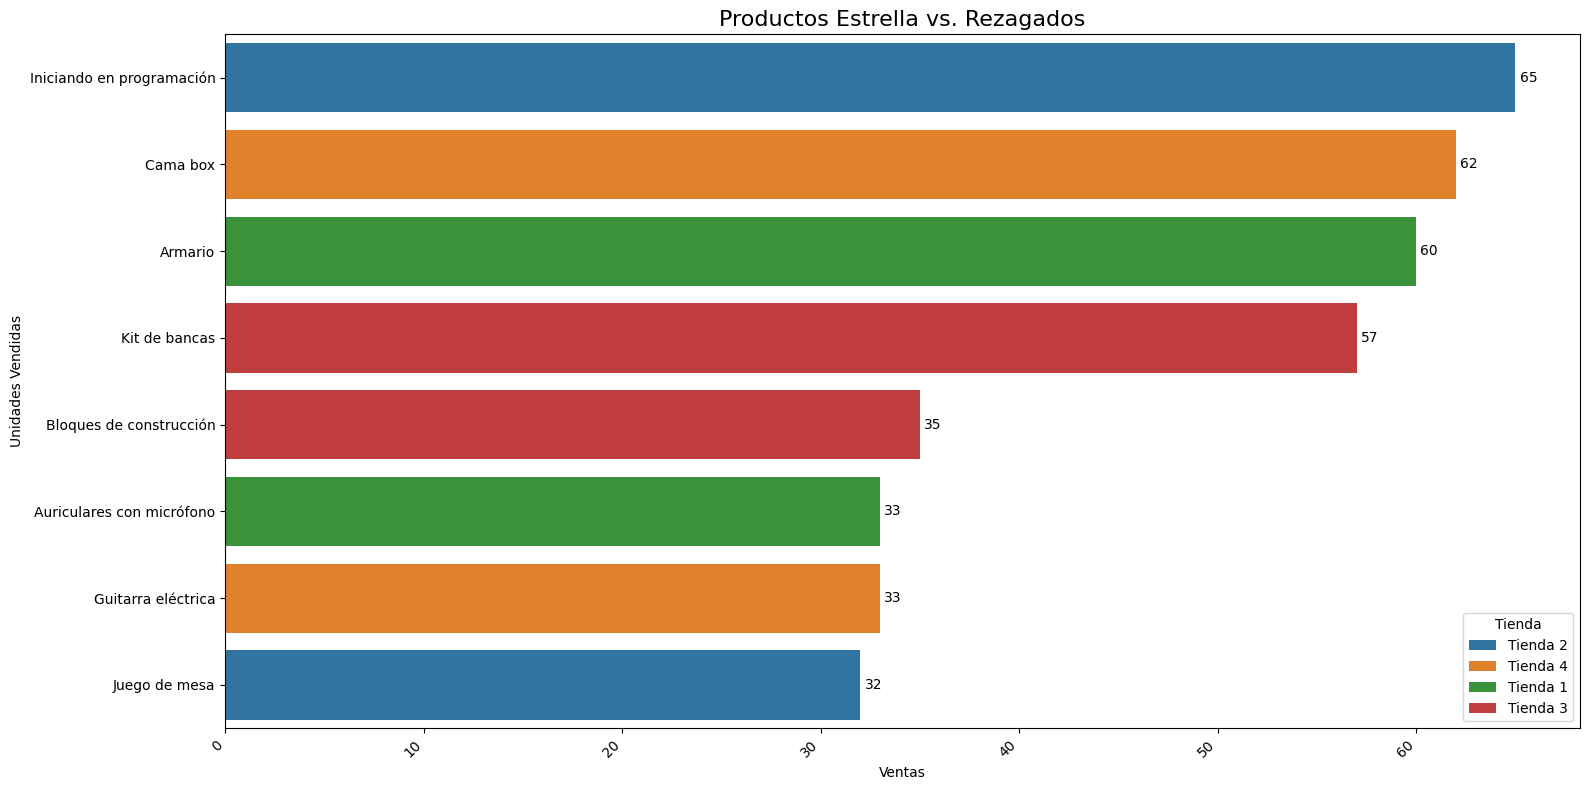

In [54]:

# Aseguramos el conteo de ventas por producto y tienda
conteo_productos = df_total.groupby(['Tienda', 'Producto']).size().reset_index(name='Ventas')

# Creamos una lista para almacenar los extremos ordenados
extremos_ordenados = []

# Iteramos por cada tienda para capturar sus extremos y ordenarlos
for tienda in conteo_productos['Tienda'].unique():
    subset = conteo_productos[conteo_productos['Tienda'] == tienda]
    top = subset.sort_values(by='Ventas', ascending=False).head(1)
    bottom = subset.sort_values(by='Ventas', ascending=True).head(1)
    extremos_ordenados.append(top)
    extremos_ordenados.append(bottom)

df_extremos = pd.concat(extremos_ordenados)

# Ordenamos el DataFrame final por 'Ventas' de mayor a menor
df_extremos = df_extremos.sort_values(by='Ventas', ascending=False)

# Creamos el gráfico
plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=df_extremos,
    x='Ventas',
    y='Producto',
    hue='Tienda',
    dodge=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Productos Estrella vs. Rezagados', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Unidades Vendidas')
plt.tight_layout()
plt.show()

Se puede observar que el producto "Iniciando en programación" es el producto más venido. Así mismo, se observa que "Juego de mesa" es el producto menos vendido.

# 5. Envío promedio por tienda

/tmp/ipykernel_570/3671055615.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


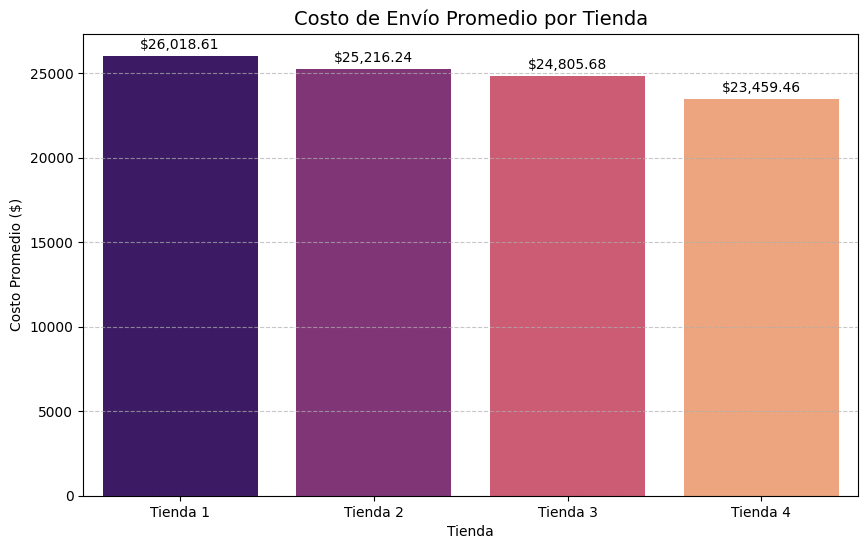

Resumen de costo de envío promedio:
     Tienda  Costo de envío
0  Tienda 1    26018.609580
1  Tienda 2    25216.235693
2  Tienda 3    24805.680373
3  Tienda 4    23459.457167


In [52]:
#Agrupamos por Tienda y calculamos el promedio de la columna 'Costo de envío'
envio_promedio = df_total.groupby('Tienda')['Costo de envío'].mean().reset_index()

#Visualización: Gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=envio_promedio,
    x='Tienda',
    y='Costo de envío',
    palette='magma'
)

#Agregar etiquetas con el valor promedio exacto
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.2f}', padding=3)

plt.title('Costo de Envío Promedio por Tienda', fontsize=14)
plt.ylabel('Costo Promedio ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Mostrar resumen en tabla
print("Resumen de costo de envío promedio:")
print(envio_promedio)

Se observa que la tienda 1 es la que posee el mayor costo de envío y la tienda 4 el menor costo de envío.


Conclusión general y recomendación


Se recomienda vender la Tienda 1, debido a los siguientes motivos:

La Tienda 1 presenta el costo de envío más alto de toda la red, lo que reduce los márgenes de beneficio a largo plazo.

A pesar de ser la que más factura, es la sucursal con menos valoración por parte de los clientes.

Al ser la tienda que más vende, su valor al mercado es mayor. Lo que podría maximizar el retorno de la inversión.